In [2]:
import sys
!{sys.executable} -m pip install abess

  Using cached abess-0.4.11-cp313-cp313-win_amd64.whl.metadata (10 kB)
Using cached abess-0.4.11-cp313-cp313-win_amd64.whl (559 kB)


In [1]:
import pandas as pd
import numpy as np
from abess import LogisticRegression as AbessLogistic
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, accuracy_score

# ---------- 1. Load data ----------
df = pd.read_csv("credit.csv")

# ---------- 2. Log transform skewed variables ----------
df['amount_log'] = np.log(df['amount'])
df['age_log'] = np.log(df['age'])
df = df.drop(columns=['amount', 'age'])

# ---------- 3. Set up X and Y ----------
y = df['default'].map({1: 0, 2: 1})     # 0 = good credit, 1 = bad credit/default
X = df.drop(columns=['default'])

cat_base_cols = X.select_dtypes(include='object').columns.tolist()  # original categorical column names, saved BEFORE dummy encoding
X = pd.get_dummies(X, drop_first=True)   # convert categorical columns into 0/1 dummy columns

# ---------- 4. Build a group index so best-subset selects whole ORIGINAL variables ----------
# (a categorical variable's dummy columns all get the same group id, so abess
# selects them together as one unit - no separate "restore all levels" step needed)
base_cols = [c for c in X.columns if not any(c.startswith(b + '_') for b in cat_base_cols)] + cat_base_cols
group_map, next_id, groups = {}, 0, []
for col in X.columns:
    base = col if col in cat_base_cols else next((b for b in cat_base_cols if col.startswith(b + '_')), col)
    if base not in group_map:
        group_map[base] = next_id
        next_id += 1
    groups.append(group_map[base])
n_groups = next_id
print("Original variables going into selection:", n_groups)
print()

# ---------- 5. Train / Validation / Test split (60/20/20) ----------
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ---------- 6. Best-subset selection (abess), cross-validated over how many variables to keep ----------
abess_model = AbessLogistic(support_size=range(0, n_groups + 1), group=np.array(groups), cv=5)
abess_model.fit(X_train.values.astype(float), y_train.values.astype(float))

selected = [c for c, coef in zip(X_train.columns, abess_model.coef_) if coef != 0]
selected_bases = sorted(set(
    c if c in cat_base_cols else next((b for b in cat_base_cols if c.startswith(b + '_')), c)
    for c in selected
))

print("Best-subset selected (dummy columns):", len(selected))
print(selected)
print()
print("...which corresponds to", len(selected_bases), "original variables:", selected_bases)
print()

# ---------- 7. Refit final model in statsmodels (for p-values, coefficients, z-stats) ----------
# abess doesn't produce p-values, so refit the selected variables in statsmodels for inference
X_train_final = sm.add_constant(X_train[selected].astype(float))
final_model = sm.Logit(y_train, X_train_final).fit()
print(final_model.summary())
print()

# ---------- 7b. Odds ratios + plain-English % change, for easy interpretation ----------
odds_ratios = np.exp(final_model.params)
pct_change = (odds_ratios - 1) * 100
interpretation = pd.DataFrame({
    "coef": final_model.params,
    "p_value": final_model.pvalues,
    "odds_ratio": odds_ratios,
    "pct_change_in_odds": pct_change
})
print(interpretation.round(4))
print()

# ---------- 8. VIF check ----------
vif_data = pd.DataFrame()
vif_data["variable"] = X_train_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) for i in range(X_train_final.shape[1])]
print(vif_data)
print()

# ---------- 9. Misclassification rate + confusion matrix (train/val/test) ----------
def evaluate(X_set, y_set, name):
    X_eval = sm.add_constant(X_set[selected].astype(float), has_constant='add')
    pred_prob = final_model.predict(X_eval)
    pred_class = (pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_set, pred_class)
    misclass = 1 - acc
    cm = confusion_matrix(y_set, pred_class)
    print(f"--- {name} ---")
    print("Misclassification rate:", round(misclass, 4))
    print("Confusion matrix:\n", cm)
    print()

evaluate(X_train, y_train, "Train")
evaluate(X_val, y_val, "Validation")
evaluate(X_test, y_test, "Test")

Original variables going into selection: 20

Best-subset selected (dummy columns): 36
['months_loan_duration', 'installment_rate', 'existing_credits', 'amount_log', 'age_log', 'checking_balance_< 0 DM', 'checking_balance_> 200 DM', 'checking_balance_unknown', 'credit_history_delayed', 'credit_history_fully repaid', 'credit_history_fully repaid this bank', 'credit_history_repaid', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture', 'purpose_others', 'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining', 'savings_balance_501 - 1000 DM', 'savings_balance_< 100 DM', 'savings_balance_> 1000 DM', 'savings_balance_unknown', 'personal_status_female', 'personal_status_married male', 'personal_status_single male', 'other_debtors_guarantor', 'other_debtors_none', 'installment_plan_none', 'installment_plan_stores', 'housing_own', 'housing_rent', 'telephone_yes', 'foreign_worker_yes']

...which corresponds to 15 original variable

Final variables: 21
['amount_log', 'age_log', 'checking_balance_< 0 DM', 'checking_balance_> 200 DM', 'checking_balance_unknown', 'credit_history_delayed', 'credit_history_fully repaid', 'credit_history_fully repaid this bank', 'credit_history_repaid', 'purpose_car (new)', 'purpose_car (used)', 'purpose_domestic appliances', 'purpose_education', 'purpose_furniture', 'purpose_others', 'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining', 'installment_plan_none', 'installment_plan_stores', 'telephone_yes']

Optimization terminated successfully.
         Current function value: 0.496133
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  600
Model:                          Logit   Df Residuals:                      578
Method:                           MLE   Df Model:                           21
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:          

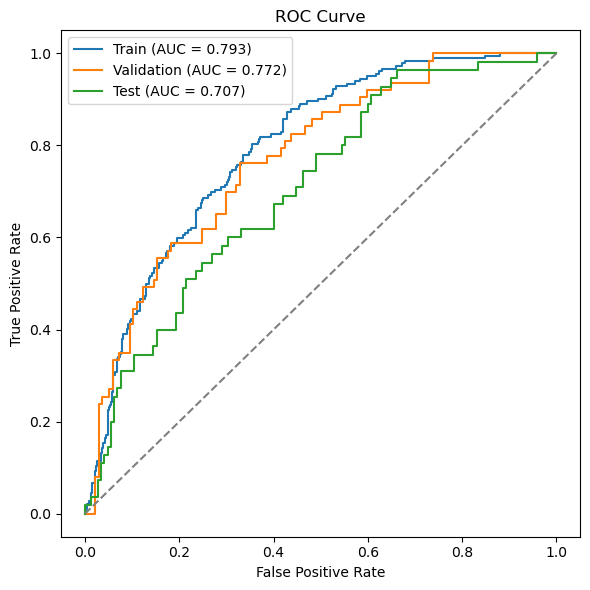

In [ ]:
# Fitting another model with dropping the insignificant variables and checking the performance of the model on train, validation and test set again. 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ---------- 1. Load data ----------
df = pd.read_csv("credit.csv")

# ---------- 2. Log transform skewed variables ----------
df['amount_log'] = np.log(df['amount'])
df['age_log'] = np.log(df['age'])
df = df.drop(columns=['amount', 'age'])

# ---------- 3. Set up X and Y ----------
y = df['default'].map({1: 0, 2: 1})     # 0 = good credit, 1 = bad credit/default
X = df.drop(columns=['default'])
X = pd.get_dummies(X, drop_first=True)

# ---------- 4. Train / Validation / Test split (60/20/20) ----------
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ---------- 5. Final variable list: best-subset result, manually minus the variables
# that turned out to have high p-values - no re-running best-subset, just this fixed list ----------
final_bases = ['age_log', 'amount_log', 'checking_balance', 'credit_history',
               'installment_plan', 'purpose', 'telephone']

selected = [c for c in X.columns
            if c in final_bases or any(c.startswith(b + '_') for b in final_bases)]

print("Final variables:", len(selected))
print(selected)
print()

# ---------- 6. Fit logistic regression directly on this final set ----------
X_train_final = sm.add_constant(X_train[selected].astype(float))
final_model = sm.Logit(y_train, X_train_final).fit()
print(final_model.summary())
print()

# ---------- 6b. Odds ratios + plain-English % change ----------
odds_ratios = np.exp(final_model.params)
pct_change = (odds_ratios - 1) * 100
interpretation = pd.DataFrame({
    "coef": final_model.params,
    "p_value": final_model.pvalues,
    "odds_ratio": odds_ratios,
    "pct_change_in_odds": pct_change
})
print(interpretation.round(4))
print()

# ---------- 7. VIF check ----------
vif_data = pd.DataFrame()
vif_data["variable"] = X_train_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) for i in range(X_train_final.shape[1])]
print(vif_data)
print()

# ---------- 8. Misclassification rate, confusion matrix, ROC AUC (train/val/test) ----------
def evaluate(X_set, y_set, name):
    X_eval = sm.add_constant(X_set[selected].astype(float), has_constant='add')
    pred_prob = final_model.predict(X_eval)
    pred_class = (pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_set, pred_class)
    misclass = 1 - acc
    cm = confusion_matrix(y_set, pred_class)
    auc = roc_auc_score(y_set, pred_prob)
    fpr, tpr, _ = roc_curve(y_set, pred_prob)
    print(f"--- {name} ---")
    print("Misclassification rate:", round(misclass, 4))
    print("ROC AUC:", round(auc, 4))
    print("Confusion matrix:\n", cm)
    print()
    return fpr, tpr, auc

results = {}
results["Train"] = evaluate(X_train, y_train, "Train")
results["Validation"] = evaluate(X_val, y_val, "Validation")
results["Test"] = evaluate(X_test, y_test, "Test")

# ---------- 9. ROC curves, all three sets on one plot ----------
plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

Optimization terminated successfully.
         Current function value: 0.498357
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  600
Model:                          Logit   Df Residuals:                      579
Method:                           MLE   Df Model:                           20
Date:                Sun, 19 Jul 2026   Pseudo R-squ.:                  0.1879
Time:                        20:23:54   Log-Likelihood:                -299.01
converged:                       True   LL-Null:                       -368.20
Covariance Type:            nonrobust   LLR p-value:                 1.032e-19
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.5695      

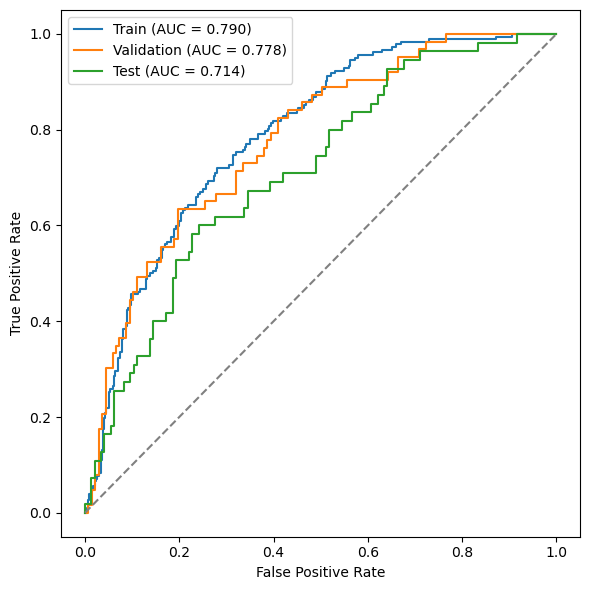

In [ ]:
# Dropping one more insignificant variable and checking the performance of the model on the final run. 

final_bases = ['age_log', 'amount_log', 'checking_balance', 'credit_history',
               'installment_plan', 'purpose']
selected = [c for c in X.columns if c in final_bases or any(c.startswith(b + '_') for b in final_bases)]

X_train_final = sm.add_constant(X_train[selected].astype(float))
final_model = sm.Logit(y_train, X_train_final).fit()
print(final_model.summary())

odds_ratios = np.exp(final_model.params)
interpretation = pd.DataFrame({
    "coef": final_model.params, "p_value": final_model.pvalues,
    "odds_ratio": odds_ratios, "pct_change_in_odds": (odds_ratios - 1) * 100
})
print(interpretation.round(4))

vif_data = pd.DataFrame()
vif_data["variable"] = X_train_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) for i in range(X_train_final.shape[1])]
print(vif_data)

def evaluate(X_set, y_set, name):
    X_eval = sm.add_constant(X_set[selected].astype(float), has_constant='add')
    pred_prob = final_model.predict(X_eval)
    pred_class = (pred_prob >= 0.5).astype(int)
    acc = accuracy_score(y_set, pred_class)
    cm = confusion_matrix(y_set, pred_class)
    auc = roc_auc_score(y_set, pred_prob)
    fpr, tpr, _ = roc_curve(y_set, pred_prob)
    print(f"--- {name} --- misclass:", round(1-acc,4), "AUC:", round(auc,4), "\n", cm)
    return fpr, tpr, auc

results = {"Train": evaluate(X_train, y_train, "Train"),
           "Validation": evaluate(X_val, y_val, "Validation"),
           "Test": evaluate(X_test, y_test, "Test")}

plt.figure(figsize=(6,6))
for name, (fpr, tpr, auc) in results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(); plt.tight_layout()
plt.show()